# **(ADD THE NOTEBOOK NAME HERE)**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\chheb\\OneDrive\\Documents\\Programming\\Unit 1 Assessment - ESG Performance\\esg_corporate_analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chheb\\OneDrive\\Documents\\Programming\\Unit 1 Assessment - ESG Performance\\esg_corporate_analysis'

# Project setup

Section 1 content

### Environment setup note

While installing project dependencies, `ppscore==1.1.0` consistently failed to build 
(`ModuleNotFoundError: No module named 'pkg_resources'`). After consulting AI, I tried two further options: upgrading `setuptools` and attempting the install with `--no-build-isolation`. Niether of these worked - meaning that I was not able to install the requirements.

Because the package's own documentation says it's not required post-analysis, and its purpose (predictive power scores as an alternative to standard correlation) is not essential to this project's methodology, I decided to remove it from `requirements.txt` (NOTE: it is commented out rather than fully deleted). Correlation between ESG pillar scores is instead assessed using pandas' `.corr()` alongside a seaborn heatmap.

## Downloading and importing project data

Project data downloaded from Kaggle: https://www.kaggle.com/datasets/alistairking/public-company-esg-ratings-dataset

I chose this dataset because....ADD TEXT 



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/public_company_esg_ratings.csv")

ModuleNotFoundError: No module named 'numpy'

## Initial exploration of the data

To start exploring the data, I used the the DISH method using the following methods and attribute:


- df.describe()
- df.info()
- df.shape
- df.head()

In [9]:
df.describe()

,environment_score,social_score,governance_score,total_score,cik
count,722.000000,722.000000,722.000000,722.000000,7.220000e+02
mean,404.806094,292.182825,278.761773,975.750693,9.897925e+05
std,145.103870,57.017406,47.031536,218.751796,5.816815e+05
min,200.000000,160.000000,75.000000,600.000000,1.800000e+03
25%,240.000000,243.000000,235.000000,763.000000,7.231572e+05
50%,483.000000,302.000000,300.000000,1046.000000,1.046189e+06
75%,518.750000,322.750000,310.000000,1144.000000,1.470094e+06
max,719.000000,667.000000,475.000000,1536.000000,1.914023e+06


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ticker                722 non-null    object
 1   name                  722 non-null    object
 2   currency              722 non-null    object
 3   exchange              722 non-null    object
 4   industry              709 non-null    object
 5   logo                  702 non-null    object
 6   weburl                706 non-null    object
 7   environment_grade     722 non-null    object
 8   environment_level     722 non-null    object
 9   social_grade          722 non-null    object
 10  social_level          722 non-null    object
 11  governance_grade      722 non-null    object
 12  governance_level      722 non-null    object
 13  environment_score     722 non-null    int64 
 14  social_score          722 non-null    int64 
 15  governance_score      722 non-null    in

In [6]:
df.shape

(722, 21)

In [7]:
df.head()

,ticker,name,currency,exchange,industry,logo,weburl,environment_grade,environment_level,social_grade,...,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,last_processing_date,total_grade,total_level,cik
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/ef50b4a2b263c84...,https://thewaltdisneycompany.com/,A,High,BB,...,BB,Medium,510,316,321,1147,19-04-2022,BBB,High,1744489
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,https://static.finnhub.io/logo/9253db78-80c9-1...,https://www.gm.com/,A,High,BB,...,B,Medium,510,303,255,1068,17-04-2022,BBB,High,1467858
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,https://static.finnhub.io/logo/f153dcda-80eb-1...,https://www.grainger.com/,B,Medium,BB,...,B,Medium,255,385,240,880,19-04-2022,BB,Medium,277135
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,https://static.finnhub.io/logo/26868a62-80ec-1...,https://mohawkind.com/,A,High,B,...,BB,Medium,570,298,303,1171,18-04-2022,BBB,High,851968
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/1cd144d2-80ec-1...,https://www.livenationentertainment.com/,BBB,High,BB,...,B,Medium,492,310,250,1052,18-04-2022,BBB,High,1335258


## Initial observation 

Running .describe() on the dataset shows that the three ESG pillar scores are not measured on a consistent scale: 

- environment_score (mean ≈ 405, range 200-719)
- social_score (mean ≈ 292, range 160–667)
- governance_score (mean ≈ 279, range 75–475) 

This means that both social and governance are both notably lower and narrower in range. This needs to be addressed before analysis because comparing raw scores directly would make almost every company appear "Environment-heavy" by default. Before we can make any cross-pillar comparisons, the scores will need to be normalised onto a common scale (e.g. min-max scaling) so that imbalance reflects real differences in relative performance rather than differences in how each pillar happens to be scored.

## Looking for outliers

This [article] (https://pub.towardsai.net/a-practical-walkthrough-of-min-max-scaling-ee5c04ba5b6e) on min-max scaling says that any single extreme outlier will compress all the other “normal” data points into a very narrow range, losing a lot of the variance in the original data.

A box plot is the best way to quickly see if there are any extreme outliers in our data set.

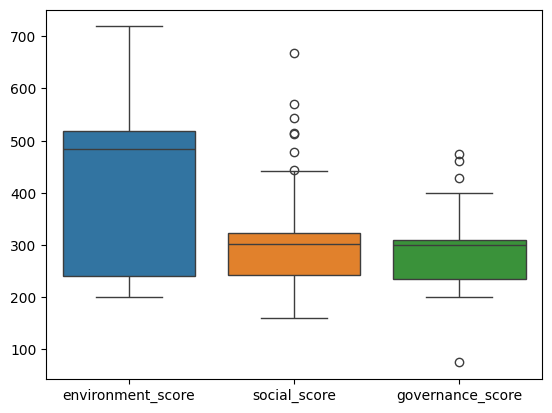

In [6]:
sns.boxplot(data=df[["environment_score", "social_score", "governance_score"]])
plt.show()

## Investigating outliers

The single low outlier for governance requires further investigation in order to determine whether it is a genuine outlier or data error. I start by filtering the data set to pull out all rows below 100. This will give me the name, sector and governance score. I then pulled the whole row to verfiy whether the other information we have about the company is consistent.

After looking at the data and investigating further online, I decide that CMS Energy's governance_score (75) is most likely a genuine, internally-consistent extreme value rather than a data error. It looks consistent when verified by cross-checking grade/level/score agreement.

It is also important to note that the information about the dataset on Kaggle does not say which third-party agency produced these ratings or their exact methodology. This is a limitation of the dataset, not just this one data point. 

In [5]:
gov_low_outlier = df[df['governance_score'] < 100][['name', 'industry', 'governance_score']]
gov_low_outlier

,name,industry,governance_score
457,CMS Energy Corp,Utilities,75


In [7]:
df.loc[457]

ticker                                                                cms
name                                                      CMS Energy Corp
currency                                                              USD
exchange                                    NEW YORK STOCK EXCHANGE, INC.
industry                                                        Utilities
logo                    https://static.finnhub.io/logo/a772ceae-80eb-1...
weburl                                         https://www.cmsenergy.com/
environment_grade                                                     BBB
environment_level                                                    High
social_grade                                                           AA
social_level                                                    Excellent
governance_grade                                                        C
governance_level                                                      Low
environment_score                     

I decide to repeat this process for the high outliers in both social and governance.

Filtering for governance scores of over 400 returns a small cluster of companies, all of which received a governance_grade of "BBB" and a governance_level of "High." I confirm this by using .unique() across the full dataset and seeing that no company received an "Excellent" governance level anywhere in the dataset. This suggests governance ratings in this dataset may have an effective ceiling below the top tier. I check the social and environment pillars and confirm this pattern is NOT repeated - both have instances of companies achieving "AA" grades and "excellent" levels. The lack of information about rating agency methodology makes it hard to judge whether this shows a trend refelcting company performance or the result of the rating criteria.

Filtering for social scores of over  450 returns several companies, all internally consistent between score, grade, and level. 

The most notable result is that CMS Energy (the same company identified earlier as the dataset's single low governance outlier) is also the highest-scoring company on Social. It is the only company in the entire dataset to receive an "AA" grade and "Excellent" level on the social pillar.

This seems to be a direct early example of a company can score exceptionally well on one ESG pillar while performing exceptionally poorly on another. 

In [8]:
gov_high_outlier = df[df['governance_score'] > 400][['name', 'industry', 'governance_score', 'governance_grade', 'governance_level']]
gov_high_outlier

,name,industry,governance_score,governance_grade,governance_level
112,Akoustis Technologies Inc,Electrical Equipment,428,BBB,High
137,Amazon.com Inc,Retail,460,BBB,High
253,Amphenol Corp,Electrical Equipment,475,BBB,High


In [9]:
social_high_outlier = df[df['social_score'] > 450][['name', 'industry', 'social_score', 'social_grade', 'social_level']]
social_high_outlier

,name,industry,social_score,social_grade,social_level
18,Airbnb Inc,Hotels Restaurants and Leisure,570,A,High
302,Edison International,Utilities,513,A,High
363,Pinnacle West Capital Corp,Utilities,479,BBB,High
452,Conocophillips,Energy,544,A,High
457,CMS Energy Corp,Utilities,667,AA,Excellent
564,Yelp Inc,Media,515,A,High


---

In [12]:

df['governance_level'].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [11]:
df['governance_grade'].unique()

array(['BB', 'B', 'BBB', 'C'], dtype=object)

In [14]:
df['environment_grade'].unique()

array(['A', 'B', 'BBB', 'BB', 'AA'], dtype=object)

In [15]:
df['environment_level'].unique()

array(['High', 'Medium', 'Excellent'], dtype=object)

In [16]:
df['social_level'].unique()

array(['Medium', 'High', 'Low', 'Excellent'], dtype=object)

In [18]:
df['social_grade'].unique()

array(['BB', 'B', 'A', 'BBB', 'CCC', 'AA'], dtype=object)

# Cleaning and preparing the data

To get the data ready for analysis, I took the following steps:

1. create df_clean = df.copy() so the raw dataframe stays available for comparison throughout.
2. Drop irrelevant/non-analytical columns by excluding cik, logo and weburl from analysis.
3. Check for duplicate rows — run .duplicated() on the full dataframe.
4. Check for duplicate companies specifically.
5. Check categorical consistency in industry — run .unique(), scan for near-duplicate labels and correct any inconsistencies (capitalisation, spacing, naming inconsistencies).
6. Handle missing values in industry — decide whether to drop those rows, leave them out of industry-level comparisons, or impute.
8. Decide on last_processing_date — is it needed for our analysis at all?
9. Re-run .info() and .isnull().sum() on the cleaned dataframe to confirm all planned changes were applied correctly.
10. Apply min-max normalisation to environment_score, social_score, governance_score to get the data ready for analysis and visualisation.

1. Creating a new data frame:

In [8]:
df_clean = df.copy()

df_clean.head()

NameError: name 'df' is not defined

2. Removing unnecessary columns

In [ ]:
df_clean = df_clean.drop(columns=['cik', 'weburl', 'logo'])

3. 

## Summary of data cleaning and preparation

TBC

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
